# Group 1 - CODA-018-RMT
- Marshal Renjiro Rifath
- Yohanes Bos
- Azward Nurfauzan
- Herlina

Proyek ini menganalisis faktor-faktor yang memengaruhi gagal bayar pinjaman kendaraan menggunakan pipeline ETL berbasis PySpark dan Apache Airflow. Data hasil transformasi disimpan di PostgreSQL NeonDB dengan star schema dan divisualisasikan menggunakan Tableau untuk memberikan insight mengenai risiko nasabah dan performa pinjaman.

# Identifikasi Masalah
## Topik Permasalahan
Mengidentifikasi karakteristik pelanggan dan faktor finansial yang memengaruhi risiko loan default pada pembiayaan kendaraan di NBFI untuk mendukung proses persetujuan kredit yang lebih efektif.

## Latar Belakang
NBFI mengalami peningkatan jumlah pelanggan yang gagal membayar cicilan kendaraan (loan default). Tingginya tingkat default menyebabkan meningkatnya risiko kredit, berkurangnya arus kas perusahaan, serta menurunkan profitabilitas bisnis.

Saat ini perusahaan belum mengetahui karakteristik pelanggan yang memiliki risiko gagal bayar lebih tinggi, sehingga proses persetujuan kredit masih belum optimal. Akibatnya, perusahaan membutuhkan analisis berbasis data untuk memahami faktor-faktor yang memengaruhi default dan mendukung pengambilan keputusan kredit yang lebih efektif.

## Problem Statement (SMART)

### Specific (S)
Mengidentifikasi karakteristik pelanggan, kondisi finansial, dan faktor kredit yang paling berpengaruh terhadap risiko loan default pada pembiayaan kendaraan NBFI sehingga perusahaan dapat meningkatkan kualitas proses persetujuan kredit.

### Measurable (M)
Menghasilkan analisis yang mampu mengidentifikasi faktor-faktor utama penyebab loan default serta memberikan rekomendasi berbasis data untuk membantu menurunkan tingkat loan default dan meningkatkan akurasi penilaian risiko kredit.

### Achievable (A)
Analisis dilakukan menggunakan data historis pelanggan yang mencakup profil demografi, informasi keuangan, riwayat kredit, dan status pinjaman sehingga faktor-faktor yang memengaruhi loan default dapat dievaluasi secara objektif.

### Relevant (R)
Hasil analisis akan mendukung manajemen dalam menyusun kebijakan persetujuan kredit yang lebih efektif, mengurangi risiko kredit, meningkatkan profitabilitas perusahaan, dan membangun portofolio pinjaman yang lebih sehat.

### Time-bound (T)
Analisis diselesaikan selama periode proyek dan menghasilkan rekomendasi yang dapat digunakan sebagai dasar pengambilan keputusan pada siklus evaluasi kredit berikutnya.

## Penjabaran Masalah
1. Berapa tingkat loan default pada portofolio pinjaman NBFI saat ini?
2. Kelompok pelanggan seperti apa yang paling banyak mengalami loan default?
3. Apakah kondisi finansial pelanggan berpengaruh terhadap kemungkinan terjadinya loan default?
4. Faktor kredit apa yang paling berkaitan dengan loan default?
5. Apakah terdapat perbedaan tingkat loan default berdasarkan wilayah atau jenis organisasi tempat pelanggan bekerja?
6. Apakah terdapat pola loan default berdasarkan waktu pengajuan pinjaman?
7. Bagaimana karakteristik pelanggan dengan risiko loan default tertinggi dapat diidentifikasi?
8. Bagaimana perusahaan dapat menurunkan tingkat loan default berdasarkan hasil analisis data?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

In [2]:
df = pd.read_csv('Train_Dataset.csv')

C:\Users\Azward\AppData\Local\Temp\ipykernel_20020\308385322.py:1: DtypeWarning: Columns (1,7,8,16,17,18,19,20,35) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Train_Dataset.csv')


In [3]:
df.head()

,ID,Client_Income,Car_Owned,Bike_Owned,Active_Loan,House_Own,Child_Count,Credit_Amount,Loan_Annuity,Accompany_Client,...,Client_Permanent_Match_Tag,Client_Contact_Work_Tag,Type_Organization,Score_Source_1,Score_Source_2,Score_Source_3,Social_Circle_Default,Phone_Change,Credit_Bureau,Default
0,12142509,6750,0.0,0.0,1.0,0.0,0.0,61190.55,3416.85,Alone,...,Yes,Yes,Self-employed,0.568066,0.478787,NaN,0.0186,63.0,NaN,0
1,12138936,20250,1.0,0.0,1.0,NaN,0.0,15282,1826.55,Alone,...,Yes,Yes,Government,0.563360,0.215068,NaN,NaN,NaN,NaN,0
2,12181264,18000,0.0,0.0,1.0,0.0,1.0,59527.35,2788.2,Alone,...,Yes,Yes,Self-employed,NaN,0.552795,0.329655,0.0742,277.0,0.0,0
3,12188929,15750,0.0,0.0,1.0,1.0,0.0,53870.4,2295.45,Alone,...,Yes,Yes,XNA,NaN,0.135182,0.631355,NaN,1700.0,3.0,0
4,12133385,33750,1.0,0.0,1.0,0.0,2.0,133988.4,3547.35,Alone,...,Yes,Yes,Business Entity Type 3,0.508199,0.301182,0.355639,0.2021,674.0,1.0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121856 entries, 0 to 121855
Data columns (total 40 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   ID                          121856 non-null  int64  
 1   Client_Income               118249 non-null  object 
 2   Car_Owned                   118275 non-null  float64
 3   Bike_Owned                  118232 non-null  float64
 4   Active_Loan                 118221 non-null  float64
 5   House_Own                   118195 non-null  float64
 6   Child_Count                 118218 non-null  float64
 7   Credit_Amount               118224 non-null  object 
 8   Loan_Annuity                117044 non-null  object 
 9   Accompany_Client            120110 non-null  object 
 10  Client_Income_Type          118155 non-null  object 
 11  Client_Education            118211 non-null  object 
 12  Client_Marital_Status       118383 non-null  object 
 13  Client_Gender 

In [5]:
df.describe()

,ID,Car_Owned,Bike_Owned,Active_Loan,House_Own,Child_Count,Own_House_Age,Mobile_Tag,Homephone_Tag,Workphone_Working,Client_Family_Members,Cleint_City_Rating,Application_Process_Day,Application_Process_Hour,Score_Source_1,Score_Source_2,Social_Circle_Default,Phone_Change,Credit_Bureau,Default
count,1.218560e+05,118275.000000,118232.000000,118221.000000,118195.000000,118218.000000,41761.000000,121856.000000,121856.000000,121856.000000,119446.000000,119447.000000,119428.000000,118193.000000,53021.000000,116170.000000,59928.000000,118192.000000,103316.000000,121856.000000
mean,1.216093e+07,0.342854,0.332262,0.499175,0.692060,0.417779,12.157324,0.999992,0.200499,0.281201,2.154329,2.030038,3.159736,12.063100,0.501213,0.518625,0.117428,962.106056,1.891082,0.080792
std,3.517694e+04,0.474665,0.471026,0.500001,0.461644,0.728802,12.056079,0.002865,0.400375,0.449587,0.912686,0.504407,1.759045,3.280695,0.211204,0.740248,0.107974,827.976726,1.861921,0.272517
min,1.210000e+07,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.014568,0.000005,0.000000,0.000000,0.000000,0.000000
25%,1.213046e+07,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,1.000000,0.000000,0.000000,2.000000,2.000000,2.000000,10.000000,0.333481,0.390164,0.057700,272.000000,0.000000,0.000000
50%,1.216093e+07,0.000000,0.000000,0.000000,1.000000,0.000000,9.000000,1.000000,0.000000,0.000000,2.000000,2.000000,3.000000,12.000000,0.504657,0.564978,0.088700,755.000000,1.000000,0.000000
75%,1.219139e+07,1.000000,1.000000,1.000000,1.000000,1.000000,15.000000,1.000000,0.000000,1.000000,3.000000,2.000000,5.000000,14.000000,0.673890,0.664011,0.148500,1570.000000,3.000000,0.000000
max,1.222186e+07,1.000000,1.000000,1.000000,1.000000,19.000000,69.000000,1.000000,1.000000,1.000000,16.000000,3.000000,6.000000,23.000000,0.945741,100.000000,1.000000,4185.000000,22.000000,1.000000


In [6]:
#Hitung total nilai yang hilang per kolom
missing_counts = df.isnull().sum()

# Hitung persentase nilai yang hilang per kolom
missing_percentage = (missing_counts / len(df)) * 100

# Gabungkan hasil menjadi DataFrame
missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage (%)': missing_percentage
})

print(missing_summary)

                            Missing Count  Missing Percentage (%)
ID                                      0                0.000000
Client_Income                        3607                2.960051
Car_Owned                            3581                2.938715
Bike_Owned                           3624                2.974002
Active_Loan                          3635                2.983029
House_Own                            3661                3.004366
Child_Count                          3638                2.985491
Credit_Amount                        3632                2.980567
Loan_Annuity                         4812                3.948923
Accompany_Client                     1746                1.432839
Client_Income_Type                   3701                3.037191
Client_Education                     3645                2.991236
Client_Marital_Status                3473                2.850085
Client_Gender                        2413                1.980206
Loan_Contr

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.drop(columns=['ID', 'Mobile_Tag', 'Homephone_Tag', 'Workphone_Working', 'Application_Process_Day', 'Client_Contact_Work_Tag', 'Registration_Days', 'Client_Gender', 'Bike_Owned'], inplace=True)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121856 entries, 0 to 121855
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Client_Income               118249 non-null  object 
 1   Car_Owned                   118275 non-null  float64
 2   Active_Loan                 118221 non-null  float64
 3   House_Own                   118195 non-null  float64
 4   Child_Count                 118218 non-null  float64
 5   Credit_Amount               118224 non-null  object 
 6   Loan_Annuity                117044 non-null  object 
 7   Accompany_Client            120110 non-null  object 
 8   Client_Income_Type          118155 non-null  object 
 9   Client_Education            118211 non-null  object 
 10  Client_Marital_Status       118383 non-null  object 
 11  Loan_Contract_Type          118205 non-null  object 
 12  Client_Housing_Type         118169 non-null  object 
 13  Population_Reg

In [10]:
kolom_diperbaiki = ['Client_Income', 'Credit_Amount', 'Loan_Annuity', 'Population_Region_Relative', 'Score_Source_3']

for cols in kolom_diperbaiki:
    df = df[df[cols]!='$']
    df = df[df[cols]!='#VALUE!']
    df = df[df[cols]!='@']
    df = df[df[cols]!='#']
    df = df[df[cols]!='&']

df[kolom_diperbaiki] = df[kolom_diperbaiki].astype('float')

In [11]:
cols = ['Child_Count','Age_Days', 'Employed_Days', 'ID_Days', 'Client_Family_Members', 'Cleint_City_Rating', 'Application_Process_Hour', 'Phone_Change']

for col in cols:
    df = df[df[col]!='$']
    df = df[df[col]!='#VALUE!']
    df = df[df[col]!='@']
    df = df[df[col]!='#']
    df = df[df[col]!='&']
    df = df[df[col]!='x']

df[cols] = df[cols].astype('float')

In [12]:
cols = ['Car_Owned', 'Active_Loan', 'House_Own', 'Default']

df[cols] = df[cols].astype('boolean')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 121793 entries, 0 to 121855
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Client_Income               118188 non-null  float64
 1   Car_Owned                   118212 non-null  boolean
 2   Active_Loan                 118160 non-null  boolean
 3   House_Own                   118135 non-null  boolean
 4   Child_Count                 118157 non-null  float64
 5   Credit_Amount               118162 non-null  float64
 6   Loan_Annuity                116982 non-null  float64
 7   Accompany_Client            120048 non-null  object 
 8   Client_Income_Type          118094 non-null  object 
 9   Client_Education            118150 non-null  object 
 10  Client_Marital_Status       118325 non-null  object 
 11  Loan_Contract_Type          118146 non-null  object 
 12  Client_Housing_Type         118107 non-null  object 
 13  Population_Region_R

In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Client_Income,118188.0,16865.637204,11539.205931,2565.000000,11250.000000,14400.000000,20250.000000,1.800009e+06
Child_Count,118157.0,0.417842,0.728865,0.000000,0.000000,0.000000,1.000000,1.900000e+01
Credit_Amount,118162.0,60046.227169,40351.300096,4500.000000,27000.000000,51750.000000,80865.000000,4.050000e+05
Loan_Annuity,116982.0,2721.282174,1461.532779,217.350000,1657.350000,2499.750000,3466.800000,2.250000e+04
Population_Region_Relative,116936.0,0.022602,0.413708,0.000533,0.010006,0.018850,0.028663,1.000000e+02
Age_Days,118194.0,16027.251079,4366.260115,7676.000000,12398.000000,15734.000000,19661.000000,2.520100e+04
Employed_Days,118144.0,67148.527924,138967.196955,0.000000,932.000000,2212.000000,5634.000000,3.652430e+05
ID_Days,115828.0,2987.457161,1511.899054,0.000000,1705.000000,3242.000000,4295.000000,7.197000e+03
Own_House_Age,41741.0,12.154189,12.052548,0.000000,5.000000,9.000000,15.000000,6.900000e+01
Client_Family_Members,119385.0,2.154433,0.912729,1.000000,2.000000,2.000000,3.000000,1.600000e+01


In [15]:
df['Default'].value_counts()


Default
False    111955
True       9838
Name: count, dtype: Int64

In [16]:
df['Default'].mean()


np.float64(0.08077639930045241)

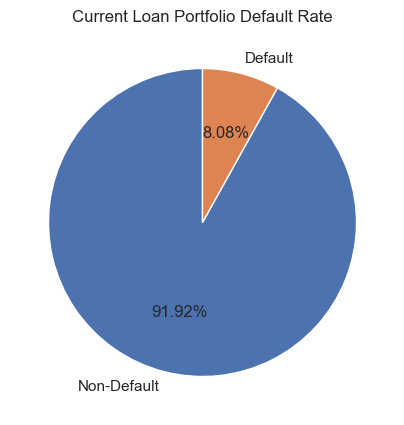

In [17]:
status = ['Non-Default', 'Default']
jumlah = [
    (df['Default'] == 0).sum(),
    (df['Default'] == 1).sum()
]

plt.figure(figsize=(5,5))
plt.pie(
    jumlah,
    labels=status,
    autopct='%1.2f%%',
    startangle=90
)

plt.title('Current Loan Portfolio Default Rate')
plt.show()

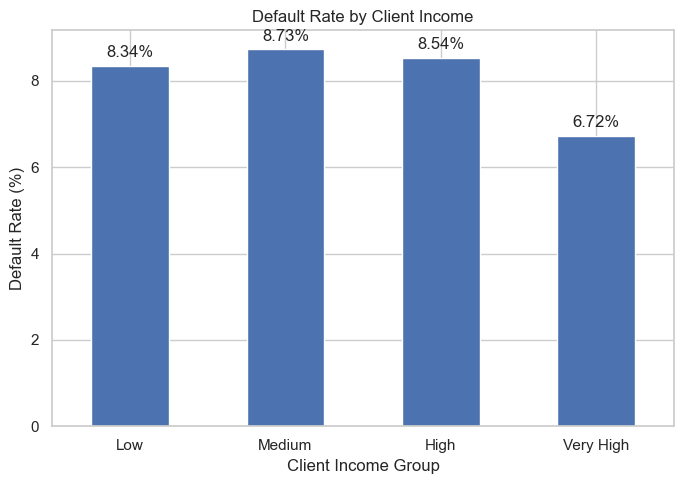

In [18]:

# Membagi Client_Income menjadi 3 kelompok
df['Income_Group'] = pd.qcut(
    df['Client_Income'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Very High'] # note : ganti range 
)

# Menghitung default rate
default_rate = df.groupby('Income_Group', observed=False)['Default'].mean() * 100

# Membuat grafik
ax = default_rate.plot(kind='bar', figsize=(7,5))

plt.xlabel('Client Income Group')
plt.ylabel('Default Rate (%)')
plt.title('Default Rate by Client Income')

# Menampilkan persentase di atas bar
for i, v in enumerate(default_rate):
    ax.text(i, v + 0.2, f'{v:.2f}%', ha='center')

plt.xticks(rotation=0) 
plt.tight_layout()
plt.show()

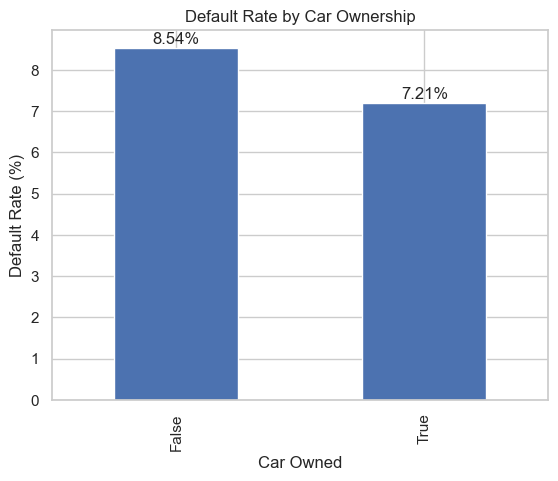

In [19]:
default_rate = df.groupby('Car_Owned')['Default'].mean() * 100

ax = default_rate.plot(kind='bar')
plt.ylabel('Default Rate (%)')
plt.xlabel('Car Owned')
plt.title('Default Rate by Car Ownership') # Note 0 sama 1 diganti kata-kata

# Menampilkan nilai persentase di atas bar

for i, v in enumerate(default_rate):

    ax.text(i, v + 0.1, f'{v:.2f}%', ha='center')

plt.show()

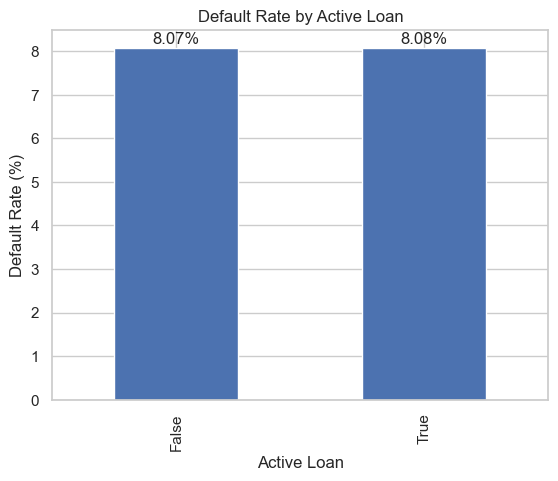

In [20]:
default_rate = df.groupby('Active_Loan')['Default'].mean() * 100

ax = default_rate.plot(kind='bar')

plt.ylabel('Default Rate (%)')
plt.xlabel('Active Loan')
plt.title('Default Rate by Active Loan')

# Menampilkan nilai persentase di atas bar

for i, v in enumerate(default_rate):

    ax.text(i, v + 0.1, f'{v:.2f}%', ha='center')

plt.show()

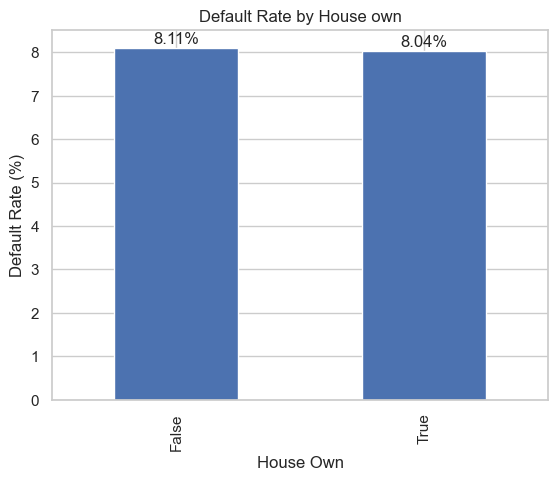

In [21]:
default_rate = df.groupby('House_Own')['Default'].mean() * 100

ax = default_rate.plot(kind='bar')
plt.ylabel('Default Rate (%)')
plt.xlabel('House Own')
plt.title('Default Rate by House own')

# Menampilkan nilai persentase di atas bar

for i, v in enumerate(default_rate):

    ax.text(i, v + 0.1, f'{v:.2f}%', ha='center')

plt.show()

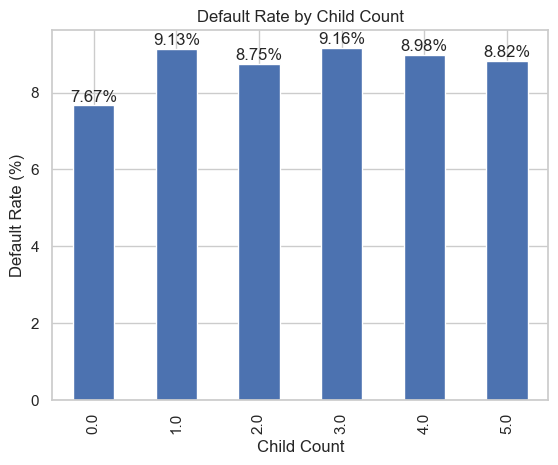

In [22]:
summary = df.groupby('Child_Count').agg(
    Total=('Default', 'count'),
    Default_Rate=('Default', 'mean')
)

summary = summary[summary['Total'] >= 30]
summary['Default_Rate'] *= 100

ax = summary['Default_Rate'].plot(kind='bar')

plt.ylabel('Default Rate (%)')
plt.xlabel('Child Count')
plt.title('Default Rate by Child Count')

for i, v in enumerate(summary['Default_Rate']):
    ax.text(i, v + 0.1, f'{v:.2f}%', ha='center')

plt.show()

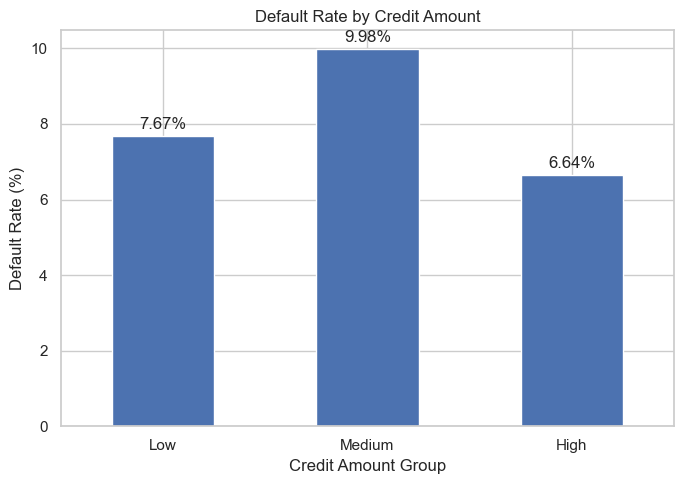

In [23]:
# Membagi menjadi 3 kelompok (Low, Medium, High)

df['Credit_Group'] = pd.qcut(df['Credit_Amount'],q=3,labels=['Low', 'Medium', 'High'])

# Menghitung default rate

default_rate = df.groupby('Credit_Group', observed=False)['Default'].mean() * 100

# Membuat grafik

ax = default_rate.plot(kind='bar', figsize=(7,5))

plt.xlabel('Credit Amount Group')

plt.ylabel('Default Rate (%)')

plt.title('Default Rate by Credit Amount')

# Menampilkan persentase di atas bar

for i, v in enumerate(default_rate):

    ax.text(i, v + 0.2, f'{v:.2f}%', ha='center')

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

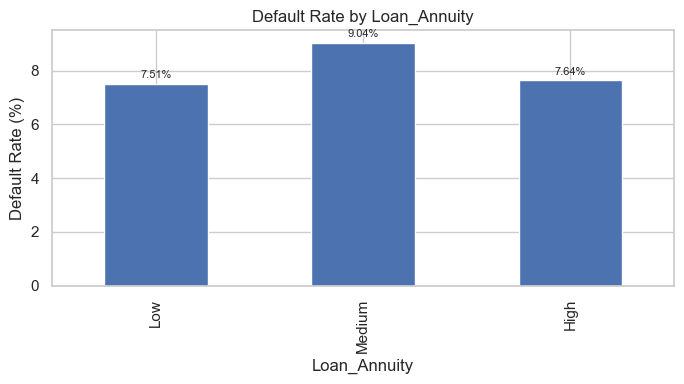

In [24]:
df['Loan_Annuity_Group']=pd.qcut(pd.to_numeric(df['Loan_Annuity'],errors='coerce'),q=3,labels=['Low','Medium','High'],duplicates='drop')
default_rate=df.groupby('Loan_Annuity_Group',observed=False)['Default'].mean()*100
ax=default_rate.plot(kind='bar',figsize=(7,4))
plt.title('Default Rate by Loan_Annuity')
plt.xlabel('Loan_Annuity')
plt.ylabel('Default Rate (%)')
for i,v in enumerate(default_rate):
    ax.text(i,v+0.2,f'{v:.2f}%',ha='center',fontsize=8)
plt.tight_layout()
plt.show()

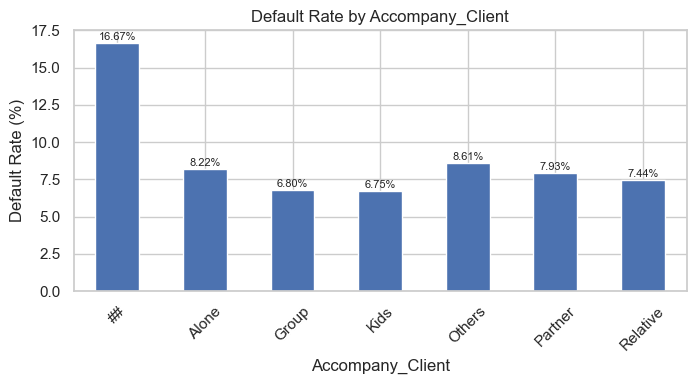

In [25]:
default_rate=df.groupby('Accompany_Client')['Default'].mean()*100
ax=default_rate.plot(kind='bar',figsize=(7,4))
plt.title('Default Rate by Accompany_Client')
plt.xlabel('Accompany_Client')
plt.ylabel('Default Rate (%)')
for i,v in enumerate(default_rate):
    ax.text(i,v+0.2,f'{v:.2f}%',ha='center',fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

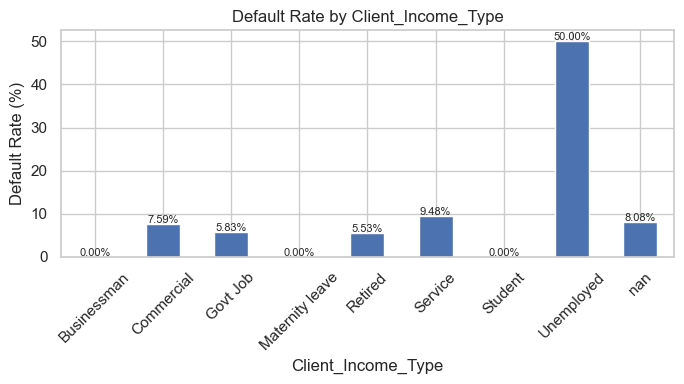

In [26]:
default_rate=df.groupby('Client_Income_Type', dropna=False)['Default'].mean()*100
ax=default_rate.plot(kind='bar',figsize=(7,4))
plt.title('Default Rate by Client_Income_Type')
plt.xlabel('Client_Income_Type')
plt.ylabel('Default Rate (%)')
for i,v in enumerate(default_rate):
    ax.text(i,v+0.2,f'{v:.2f}%',ha='center',fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

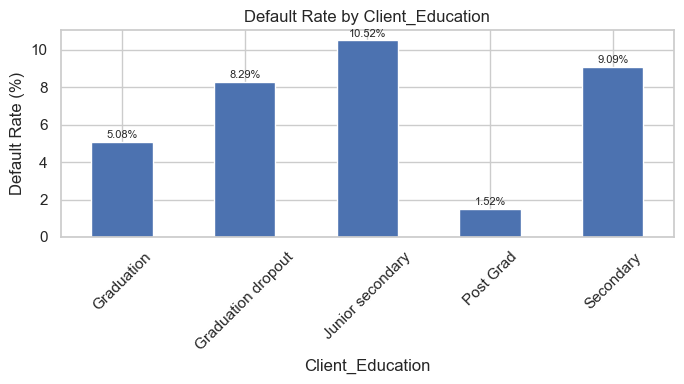

In [27]:
default_rate=df.groupby('Client_Education')['Default'].mean()*100
ax=default_rate.plot(kind='bar',figsize=(7,4))
plt.title('Default Rate by Client_Education')
plt.xlabel('Client_Education')
plt.ylabel('Default Rate (%)')
for i,v in enumerate(default_rate):
    ax.text(i,v+0.2,f'{v:.2f}%',ha='center',fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

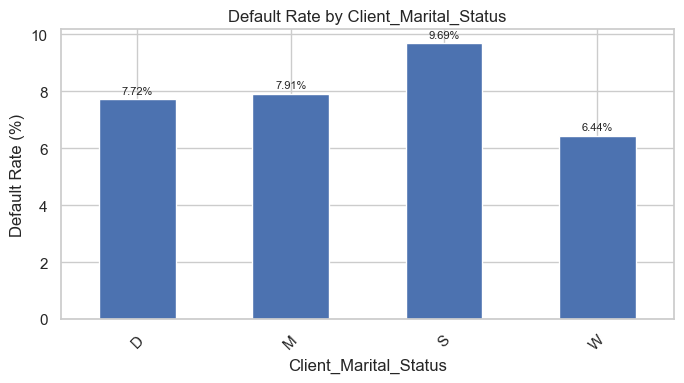

In [28]:
default_rate=df.groupby('Client_Marital_Status')['Default'].mean()*100
ax=default_rate.plot(kind='bar',figsize=(7,4))
plt.title('Default Rate by Client_Marital_Status')
plt.xlabel('Client_Marital_Status')
plt.ylabel('Default Rate (%)')
for i,v in enumerate(default_rate):
    ax.text(i,v+0.2,f'{v:.2f}%',ha='center',fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

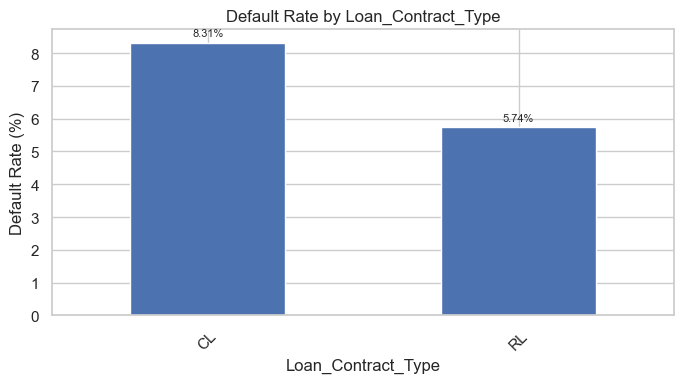

In [29]:
default_rate=df.groupby('Loan_Contract_Type')['Default'].mean()*100
ax=default_rate.plot(kind='bar',figsize=(7,4))
plt.title('Default Rate by Loan_Contract_Type')
plt.xlabel('Loan_Contract_Type')
plt.ylabel('Default Rate (%)')
for i,v in enumerate(default_rate):
    ax.text(i,v+0.2,f'{v:.2f}%',ha='center',fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

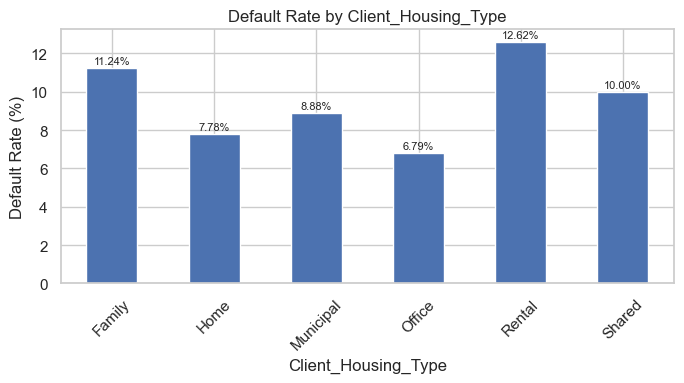

In [30]:
default_rate=df.groupby('Client_Housing_Type')['Default'].mean()*100
ax=default_rate.plot(kind='bar',figsize=(7,4))
plt.title('Default Rate by Client_Housing_Type')
plt.xlabel('Client_Housing_Type')
plt.ylabel('Default Rate (%)')
for i,v in enumerate(default_rate):
    ax.text(i,v+0.2,f'{v:.2f}%',ha='center',fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

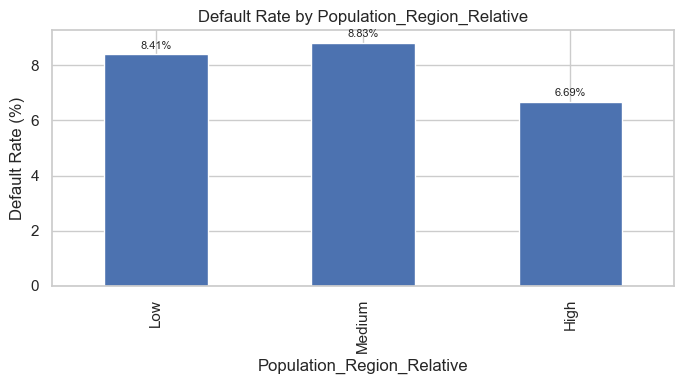

In [31]:
df['Population_Region_Relative_Group']=pd.qcut(pd.to_numeric(df['Population_Region_Relative'],errors='coerce'),q=3,labels=['Low','Medium','High'],duplicates='drop')
default_rate=df.groupby('Population_Region_Relative_Group',observed=False)['Default'].mean()*100
ax=default_rate.plot(kind='bar',figsize=(7,4))
plt.title('Default Rate by Population_Region_Relative')
plt.xlabel('Population_Region_Relative')
plt.ylabel('Default Rate (%)')
for i,v in enumerate(default_rate):
    ax.text(i,v+0.2,f'{v:.2f}%',ha='center',fontsize=8)
plt.tight_layout()
plt.show()


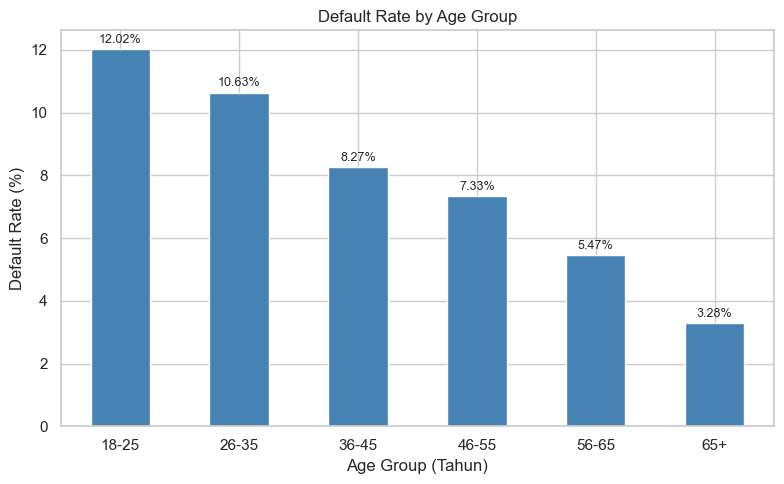

In [32]:
# Konversi hari → tahun dulu
df['Age_Years'] = pd.to_numeric(df['Age_Days'], errors='coerce').abs() / 365

# Baru buat kelompok umur dalam satuan TAHUN
df['Age_Group'] = pd.cut(
    df['Age_Years'],
    bins=[18, 25, 35, 45, 55, 65, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
)

# Hitung default rate per kelompok umur
default_rate = df.groupby('Age_Group', observed=False)['Default'].mean() * 100

# Plot
ax = default_rate.plot(kind='bar', figsize=(8, 5), color='steelblue', edgecolor='white')
plt.title('Default Rate by Age Group')
plt.xlabel('Age Group (Tahun)')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=0)
for i, v in enumerate(default_rate):
    ax.text(i, v + 0.2, f'{v:.2f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()



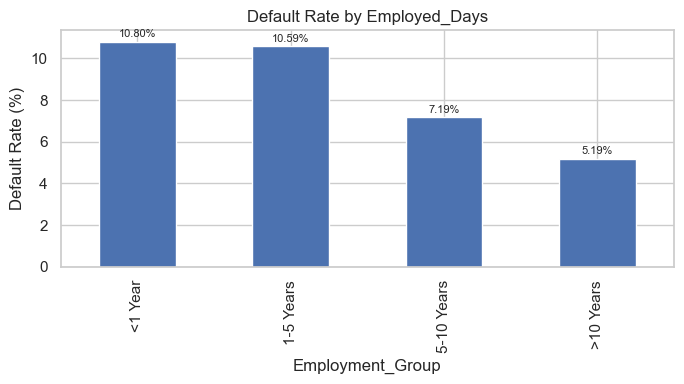

In [33]:
df['Employment_Group']=pd.cut((pd.to_numeric(df['Employed_Days'],errors='coerce').abs()/365),bins=[0,1,5,10,100],labels=['<1 Year','1-5 Years','5-10 Years','>10 Years'])
default_rate=df.groupby('Employment_Group',observed=False)['Default'].mean()*100
ax=default_rate.plot(kind='bar',figsize=(7,4))
plt.title('Default Rate by Employed_Days')
plt.ylabel('Default Rate (%)')
for i,v in enumerate(default_rate):
    ax.text(i,v+0.2,f'{v:.2f}%',ha='center',fontsize=8)
plt.tight_layout()
plt.show()

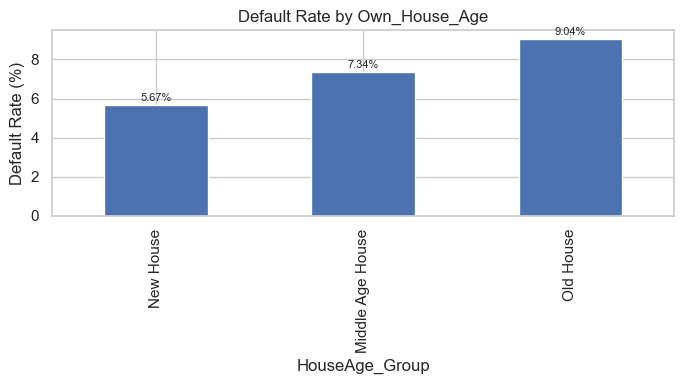

In [34]:
df['HouseAge_Group']=pd.qcut(pd.to_numeric(df['Own_House_Age'],errors='coerce'),3,labels=['New House','Middle Age House','Old House'],duplicates='drop')
default_rate=df.groupby('HouseAge_Group',observed=False)['Default'].mean()*100
ax=default_rate.plot(kind='bar',figsize=(7,4))
plt.title('Default Rate by Own_House_Age')
plt.ylabel('Default Rate (%)')
for i,v in enumerate(default_rate):
    ax.text(i,v+0.2,f'{v:.2f}%',ha='center',fontsize=8)
plt.tight_layout()
plt.show()

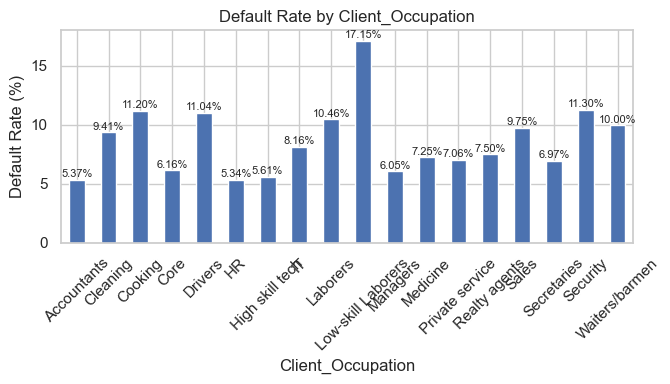

In [35]:
default_rate=df.groupby('Client_Occupation')['Default'].mean()*100
ax=default_rate.plot(kind='bar',figsize=(7,4))
plt.title('Default Rate by Client_Occupation')
plt.ylabel('Default Rate (%)')
for i,v in enumerate(default_rate):
    ax.text(i,v+0.2,f'{v:.2f}%',ha='center',fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 121793 entries, 0 to 121855
Data columns (total 39 columns):
 #   Column                            Non-Null Count   Dtype   
---  ------                            --------------   -----   
 0   Client_Income                     118188 non-null  float64 
 1   Car_Owned                         118212 non-null  boolean 
 2   Active_Loan                       118160 non-null  boolean 
 3   House_Own                         118135 non-null  boolean 
 4   Child_Count                       118157 non-null  float64 
 5   Credit_Amount                     118162 non-null  float64 
 6   Loan_Annuity                      116982 non-null  float64 
 7   Accompany_Client                  120048 non-null  object  
 8   Client_Income_Type                118094 non-null  object  
 9   Client_Education                  118150 non-null  object  
 10  Client_Marital_Status             118325 non-null  object  
 11  Loan_Contract_Type                118146 non

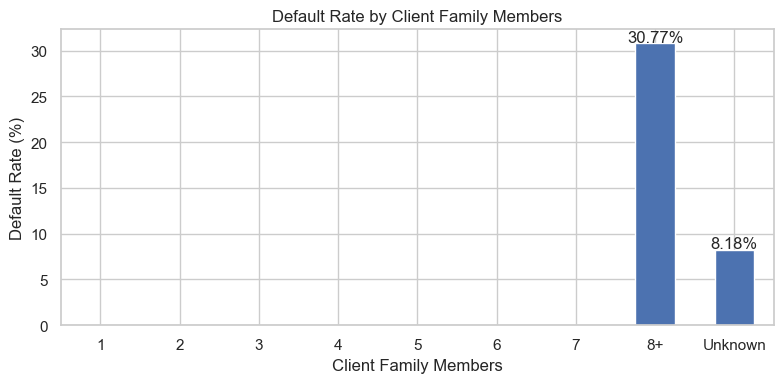

In [37]:
# Ubah ke numerik
df['Client_Family_Members'] = pd.to_numeric(
    df['Client_Family_Members'],
    errors='coerce'
)

# Salin kolom lalu ubah menjadi object
df['Family_Group'] = df['Client_Family_Members'].astype(object)

# Ubah >=8 menjadi "8+"
df.loc[df['Family_Group'] >= 8, 'Family_Group'] = '8+'

# Ubah NaN menjadi Unknown
df['Family_Group'] = df['Family_Group'].fillna('Unknown')

# Ubah menjadi string
df['Family_Group'] = df['Family_Group'].astype(str)

# Hitung default rate
default_rate = (
    df.groupby('Family_Group')['Default']
      .mean()
      .reindex(['1','2','3','4','5','6','7','8+','Unknown']) * 100
)

# Plot
ax = default_rate.plot(kind='bar', figsize=(8,4))

plt.title('Default Rate by Client Family Members')
plt.xlabel('Client Family Members')
plt.ylabel('Default Rate (%)')

for i, v in enumerate(default_rate):
    if pd.notna(v):
        ax.text(i, v + 0.2, f'{v:.2f}%', ha='center')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

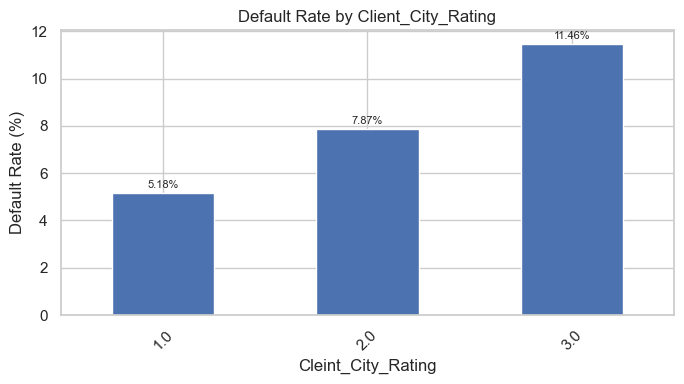

In [38]:
default_rate=df.groupby('Cleint_City_Rating')['Default'].mean()*100
ax=default_rate.plot(kind='bar',figsize=(7,4))
plt.title('Default Rate by Client_City_Rating')
plt.ylabel('Default Rate (%)')
for i,v in enumerate(default_rate):
    ax.text(i,v+0.2,f'{v:.2f}%',ha='center',fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

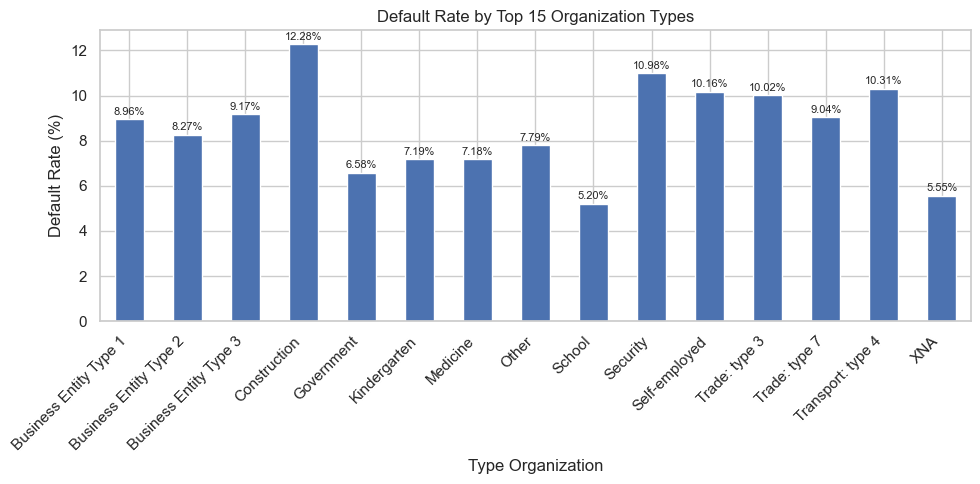

In [39]:
# Ambil 15 organisasi dengan jumlah data terbanyak
top_org = df['Type_Organization'].value_counts().head(15).index

# Hitung default rate
default_rate = (
    df[df['Type_Organization'].isin(top_org)]
      .groupby('Type_Organization')['Default']
      .mean() * 100
)

ax = default_rate.plot(kind='bar', figsize=(10,5))

plt.title('Default Rate by Top 15 Organization Types')
plt.xlabel('Type Organization')
plt.ylabel('Default Rate (%)')

for i, v in enumerate(default_rate):
    ax.text(i, v + 0.2, f'{v:.2f}%', ha='center', fontsize=8)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

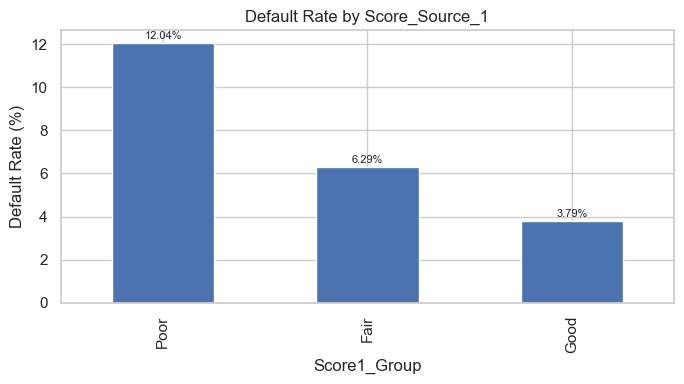

In [40]:
df['Score1_Group']=pd.qcut(pd.to_numeric(df['Score_Source_1'],errors='coerce'),3,labels=['Poor','Fair','Good'],duplicates='drop')
default_rate=df.groupby('Score1_Group',observed=False)['Default'].mean()*100
ax=default_rate.plot(kind='bar',figsize=(7,4))
plt.title('Default Rate by Score_Source_1')
plt.ylabel('Default Rate (%)')
for i,v in enumerate(default_rate):
    ax.text(i,v+0.2,f'{v:.2f}%',ha='center',fontsize=8)
plt.tight_layout()
plt.show()

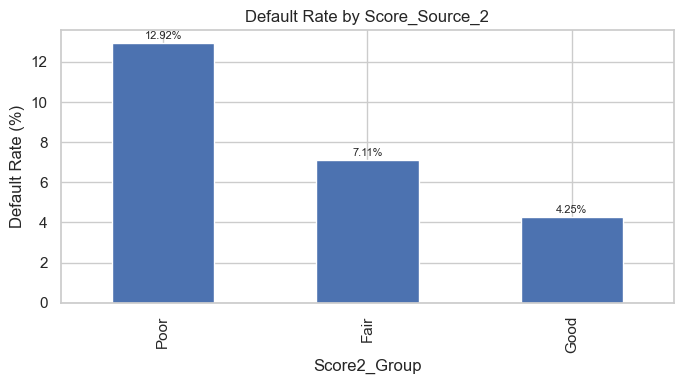

In [41]:
df['Score2_Group']=pd.qcut(pd.to_numeric(df['Score_Source_2'],errors='coerce'),3,labels=['Poor','Fair','Good'],duplicates='drop')
default_rate=df.groupby('Score2_Group',observed=False)['Default'].mean()*100
ax=default_rate.plot(kind='bar',figsize=(7,4))
plt.title('Default Rate by Score_Source_2')
plt.ylabel('Default Rate (%)')
for i,v in enumerate(default_rate):
    ax.text(i,v+0.2,f'{v:.2f}%',ha='center',fontsize=8)
plt.tight_layout()
plt.show()

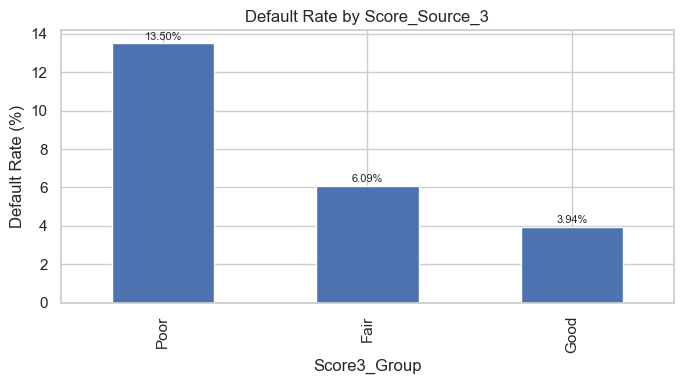

In [42]:
df['Score3_Group']=pd.qcut(pd.to_numeric(df['Score_Source_3'],errors='coerce'),3,labels=['Poor','Fair','Good'],duplicates='drop')
default_rate=df.groupby('Score3_Group',observed=False)['Default'].mean()*100
ax=default_rate.plot(kind='bar',figsize=(7,4))
plt.title('Default Rate by Score_Source_3')
plt.ylabel('Default Rate (%)')
for i,v in enumerate(default_rate):
    ax.text(i,v+0.2,f'{v:.2f}%',ha='center',fontsize=8)
plt.tight_layout()
plt.show()

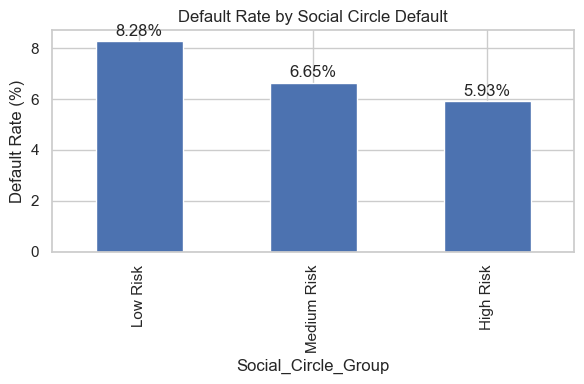

In [43]:
df['Social_Circle_Group'] = pd.qcut(
    pd.to_numeric(df['Social_Circle_Default'], errors='coerce'),
    q=3,
    labels=['Low Risk', 'Medium Risk', 'High Risk'],
    duplicates='drop'
)

default_rate = df.groupby('Social_Circle_Group', observed=False)['Default'].mean() * 100

ax = default_rate.plot(kind='bar', figsize=(6,4))

plt.title('Default Rate by Social Circle Default')
plt.ylabel('Default Rate (%)')

for i, v in enumerate(default_rate):
    ax.text(i, v+0.2, f'{v:.2f}%', ha='center')

plt.tight_layout()
plt.show()

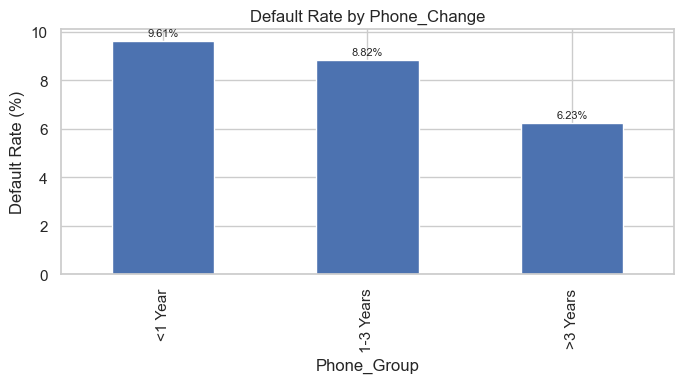

In [44]:
df['Phone_Group']=pd.cut((pd.to_numeric(df['Phone_Change'],errors='coerce').abs()/365),bins=[0,1,3,100],labels=['<1 Year','1-3 Years','>3 Years'])
default_rate=df.groupby('Phone_Group',observed=False)['Default'].mean()*100
ax=default_rate.plot(kind='bar',figsize=(7,4))
plt.title('Default Rate by Phone_Change')
plt.ylabel('Default Rate (%)')
for i,v in enumerate(default_rate):
    ax.text(i,v+0.2,f'{v:.2f}%',ha='center',fontsize=8)
plt.tight_layout()
plt.show()

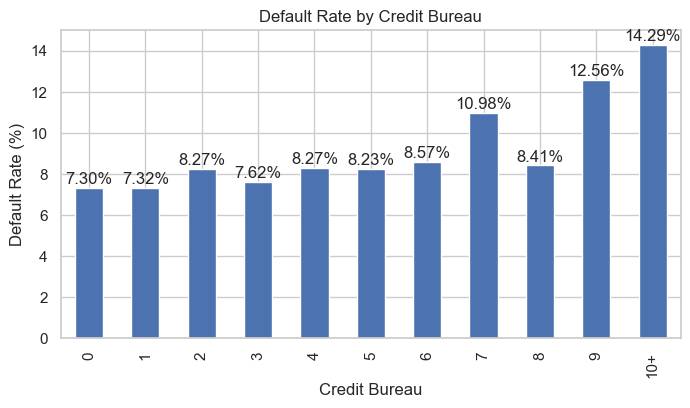

In [45]:
# Gabungkan nilai >=10 menjadi "10+"
df['Credit_Bureau_Group'] = np.where(
    df['Credit_Bureau'] >= 10,
    '10+',
    df['Credit_Bureau'].fillna(-1).astype(int).astype(str)
)

# Hitung Default Rate
default_rate = df.groupby('Credit_Bureau_Group')['Default'].mean() * 100

# Urutkan kategori
default_rate = default_rate.reindex(
    ['0','1','2','3','4','5','6','7','8','9','10+']
)

# Plot
ax = default_rate.plot(kind='bar', figsize=(8,4))

plt.title('Default Rate by Credit Bureau')
plt.xlabel('Credit Bureau')
plt.ylabel('Default Rate (%)')

for i, v in enumerate(default_rate):
    ax.text(i, v+0.2, f'{v:.2f}%', ha='center')

plt.show()


In [46]:
# Hitung nasabah Unemployed
n_total1       = len(df)
n_unemployed  = len(df[df['Client_Income_Type'] == 'Unemployed'])
n_default_unemployed = df[df['Client_Income_Type'] == 'Unemployed']['Default'].sum()

# Dataset setelah reject Unemployed
df_tanpa_unemployed = df[df['Client_Income_Type'] != 'Unemployed']

# Hitung default rate baru
n_sisa1        = len(df_tanpa_unemployed)
default_baru1  = df_tanpa_unemployed['Default'].mean() * 100
default_lama1  = df['Default'].mean() * 100

print("=" * 50)
print("SIMULASI: REJECT NASABAH UNEMPLOYED")
print("=" * 50)
print(f"\nTotal nasabah awal       : {n_total1:,}")
print(f"Nasabah Unemployed       : {n_unemployed:,} orang")
print(f"Default dari Unemployed  : {int(n_default_unemployed):,} orang")
print(f"Sisa nasabah setelah reject : {n_sisa1:,}")
print(f"\nDefault rate SEBELUM     : {default_lama1:.3f}%")
print(f"Default rate SESUDAH     : {default_baru1:.3f}%")
print(f"Penurunan                : {default_lama1 - default_baru1:.3f} ")
print("=" * 50)

SIMULASI: REJECT NASABAH UNEMPLOYED

Total nasabah awal       : 121,793
Nasabah Unemployed       : 6 orang
Default dari Unemployed  : 3 orang
Sisa nasabah setelah reject : 121,787

Default rate SEBELUM     : 8.078%
Default rate SESUDAH     : 8.076%
Penurunan                : 0.002 


In [47]:
df.shape

(121793, 46)

In [48]:
# Cek dulu berapa orang yang family members >= 8

n_sisa1 
n_family_8    = len(df_tanpa_unemployed[df_tanpa_unemployed['Client_Family_Members'] >= 8])
n_default_fm  = df_tanpa_unemployed[df_tanpa_unemployed['Client_Family_Members'] >= 8]['Default'].sum()


# Dataset setelah reject family members >= 8
df_tanpa_fm8  = df_tanpa_unemployed[(df_tanpa_unemployed['Client_Family_Members'] < 8)|(df_tanpa_unemployed['Client_Family_Members'].isna())]
n_sisa2        = len(df_tanpa_fm8)
default_baru2  = df_tanpa_fm8['Default'].mean() * 100

print("=" * 50)
print("SIMULASI: REJECT FAMILY MEMBERS >= 8")
print("=" * 50)
print(f"\nTotal nasabah awal        : {n_sisa1 :,}")
print(f"Nasabah Family Members ≥8 : {n_family_8:,} orang")
print(f"Default dari kelompok ini : {int(n_default_fm):,} orang")
print(f"Sisa nasabah setelah reject: {n_sisa2:,}")
print(f"\nDefault rate SEBELUM      : {default_lama1:.3f}%")
print(f"Default rate SESUDAH      : {default_baru2:.3f}%")
print(f"Penurunan                 : {default_lama1 - default_baru2:.3f}")
print("=" * 50)


SIMULASI: REJECT FAMILY MEMBERS >= 8

Total nasabah awal        : 121,787
Nasabah Family Members ≥8 : 26 orang
Default dari kelompok ini : 8 orang
Sisa nasabah setelah reject: 121,761

Default rate SEBELUM      : 8.078%
Default rate SESUDAH      : 8.071%
Penurunan                 : 0.007


In [49]:
# Hitung umur dari Age_Days

df_tanpa_fm8['Age'] = pd.to_numeric(df['Age_Days'], errors='coerce').abs() / 365


# Cek jumlah nasabah umur 18-25
n_sisa2 = len(df_tanpa_fm8)

n_age18_25 = len(
    df_tanpa_fm8[
        (df_tanpa_fm8['Age'] >= 18) &
        (df_tanpa_fm8['Age'] <= 25)
    ]
)

n_default_age = df_tanpa_fm8[
    (df_tanpa_fm8['Age'] >= 18) &
    (df_tanpa_fm8['Age'] <= 25)
]['Default'].sum()

# Dataset setelah reject umur 18-25
df_tanpa_age18_25 = df_tanpa_fm8[
    ~(
        (df_tanpa_fm8['Age'] >= 18) &
        (df_tanpa_fm8['Age'] <= 25)
    )
]

n_sisa3 = len(df_tanpa_age18_25)

default_baru3 = df_tanpa_age18_25['Default'].mean() * 100

print("="*50)
print("SIMULASI: REJECT NASABAH USIA 18-25")
print("="*50)

print(f"Total nasabah sebelum reject : {n_sisa2:,}")
print(f"Nasabah umur 18-25           : {n_age18_25:,}")
print(f"Default pada kelompok ini    : {int(n_default_age):,}")

print(f"Sisa nasabah                 : {n_sisa3:,}")

print(f"\nDefault rate SEBELUM : {default_baru2:.3f}%")
print(f"Default rate SESUDAH : {default_baru3:.3f}%")
print(f"Penurunan            : {default_baru2-default_baru3:.3f}%")

print("="*50)

SIMULASI: REJECT NASABAH USIA 18-25
Total nasabah sebelum reject : 121,761
Nasabah umur 18-25           : 4,667
Default pada kelompok ini    : 561
Sisa nasabah                 : 117,094

Default rate SEBELUM : 8.071%
Default rate SESUDAH : 7.913%
Penurunan            : 0.157%


C:\Users\Azward\AppData\Local\Temp\ipykernel_20020\3422267708.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tanpa_fm8['Age'] = pd.to_numeric(df['Age_Days'], errors='coerce').abs() / 365


In [50]:
# Cek jumlah nasabah dengan Score Source = 3
n_sisa3 = len(df_tanpa_age18_25)

n_score3 = len(
    df_tanpa_age18_25[
        df_tanpa_age18_25['Score3_Group'] == 'Poor'
    ]
)
df['Score3_Group']
n_default_score3 = df_tanpa_age18_25[
    df_tanpa_age18_25['Score3_Group'] == 'Poor'
]['Default'].sum()

# Dataset setelah reject Score Source = Poor
df_tanpa_score3 = df_tanpa_age18_25[
    df_tanpa_age18_25['Score3_Group'] != 'Poor'
]

n_sisa4 = len(df_tanpa_score3)

default_baru4 = df_tanpa_score3['Default'].mean() * 100

print("="*50)
print("SIMULASI: REJECT SCORE SOURCE = 3")
print("="*50)

print(f"Total nasabah sebelum reject : {n_sisa3:,}")
print(f"Nasabah Score Source = 3     : {n_score3:,}")
print(f"Default pada kelompok ini    : {int(n_default_score3):,}")
print(f"Sisa nasabah                 : {n_sisa4:,}")

print(f"\nDefault rate SEBELUM : {default_baru3:.3f}%")
print(f"Default rate SESUDAH : {default_baru4:.3f}%")
print(f"Penurunan            : {(default_baru3-default_baru4):.3f}%")

print("="*50)

SIMULASI: REJECT SCORE SOURCE = 3
Total nasabah sebelum reject : 117,094
Nasabah Score Source = 3     : 29,893
Default pada kelompok ini    : 3,995
Sisa nasabah                 : 87,201

Default rate SEBELUM : 7.913%
Default rate SESUDAH : 6.045%
Penurunan            : 1.869%


In [51]:
print(df_tanpa_fm8['Age_Days'].dtype)

float64


In [52]:
df_tanpa_unemployed['Client_Family_Members'].value_counts(dropna=False)

Client_Family_Members
2.0     61618
1.0     26192
3.0     20425
4.0      9580
NaN      2408
5.0      1349
6.0       157
7.0        32
8.0        11
9.0         4
10.0        3
12.0        3
16.0        2
13.0        1
14.0        1
15.0        1
Name: count, dtype: int64

In [53]:
df_tanpa_fm8['Client_Family_Members'].value_counts(dropna=False)

Client_Family_Members
2.0    61618
1.0    26192
3.0    20425
4.0     9580
NaN     2408
5.0     1349
6.0      157
7.0       32
Name: count, dtype: int64

In [54]:
len(df)

121793

In [55]:
df['Client_Family_Members'].dtypes

dtype('float64')

Default Rate per Kelompok Pendapatan:
Quartile
Q1 Rendah    8.34
Q2           8.73
Q3           8.54
Q4 Tinggi    6.72

Default Rate per Beban Cicilan:
Quartile_Cicilan
Q1 Ringan    7.45
Q2           7.67
Q3           8.58
Q4 Berat     8.61


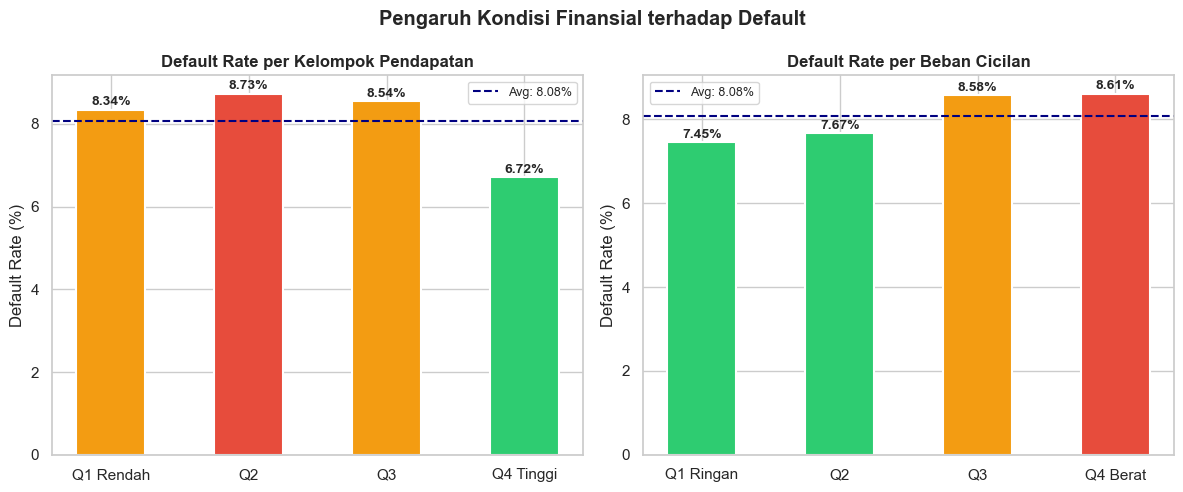

In [56]:
df['Client_Income']  = pd.to_numeric(df['Client_Income'],  errors='coerce')
df['Loan_Annuity']   = pd.to_numeric(df['Loan_Annuity'],   errors='coerce')
df['Default']        = pd.to_numeric(df['Default'],        errors='coerce')
df['Rasio_Cicilan']  = df['Loan_Annuity'] / df['Client_Income']

# ── Quartile Income ──────────────────────────────────────────
temp = df.dropna(subset=['Client_Income']).copy()
temp['Quartile'] = pd.qcut(temp['Client_Income'], q=4,
    labels=['Q1 Rendah', 'Q2', 'Q3', 'Q4 Tinggi'])

hasil = temp.groupby('Quartile', observed=True)['Default'].mean() * 100

# ── Quartile Rasio Cicilan ───────────────────────────────────
temp2 = df.dropna(subset=['Rasio_Cicilan']).copy()
temp2 = temp2[temp2['Rasio_Cicilan'].between(0, 2)]
temp2['Quartile_Cicilan'] = pd.qcut(temp2['Rasio_Cicilan'], q=4,
    labels=['Q1 Ringan', 'Q2', 'Q3', 'Q4 Berat'])

dr_cicilan = temp2.groupby('Quartile_Cicilan',
                observed=True)['Default'].mean() * 100

print("Default Rate per Kelompok Pendapatan:")
print(hasil.round(2).to_string())
print("\nDefault Rate per Beban Cicilan:")
print(dr_cicilan.round(2).to_string())

# ── Warna Otomatis Berdasarkan Nilai ────────────────────────
def auto_warna(series):
    return ['#E74C3C' if v == series.max()       # merah  = tertinggi
            else '#F39C12' if v > series.mean()  # kuning = di atas rata-rata
            else '#2ECC71'                        # hijau  = di bawah rata-rata
            for v in series.values]

# ── Visualisasi ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel Kiri — Income
bars = axes[0].bar(hasil.index, hasil.values,
                   color=auto_warna(hasil),
                   edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, hasil.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'{val:.2f}%', ha='center',
                 fontsize=10, fontweight='bold')
axes[0].axhline(df['Default'].mean()*100, color='navy',
                linestyle='--', linewidth=1.5,
                label=f"Avg: {df['Default'].mean()*100:.2f}%")
axes[0].set_title('Default Rate per Kelompok Pendapatan',
                  fontweight='bold')
axes[0].set_ylabel('Default Rate (%)')
axes[0].legend(fontsize=9)

# Panel Kanan — Rasio Cicilan
bars2 = axes[1].bar(dr_cicilan.index, dr_cicilan.values,
                    color=auto_warna(dr_cicilan),
                    edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars2, dr_cicilan.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'{val:.2f}%', ha='center',
                 fontsize=10, fontweight='bold')
axes[1].axhline(df['Default'].mean()*100, color='navy',
                linestyle='--', linewidth=1.5,
                label=f"Avg: {df['Default'].mean()*100:.2f}%")
axes[1].set_title('Default Rate per Beban Cicilan',
                  fontweight='bold')
axes[1].set_ylabel('Default Rate (%)')
axes[1].legend(fontsize=9)

plt.suptitle('Pengaruh Kondisi Finansial terhadap Default',
             fontweight='bold')
plt.tight_layout()
plt.show()


Score Source 2 per Quartile:
Q_Skor2
Q1 Rendah    14.12
Q2            8.07
Q3            6.34
Q4 Tinggi     3.86

Score Source 3 per Quartile:
Q_Skor3
Q1 Rendah    15.06
Q2            7.47
Q3            5.11
Q4 Tinggi     3.71

Tipe Kontrak:
Loan_Contract_Type
CL    8.31
RL    5.74

Credit Bureau:
CB_Group
0 Tidak Ada     7.3
1-3 Sedikit    7.71
4+ Banyak      8.64


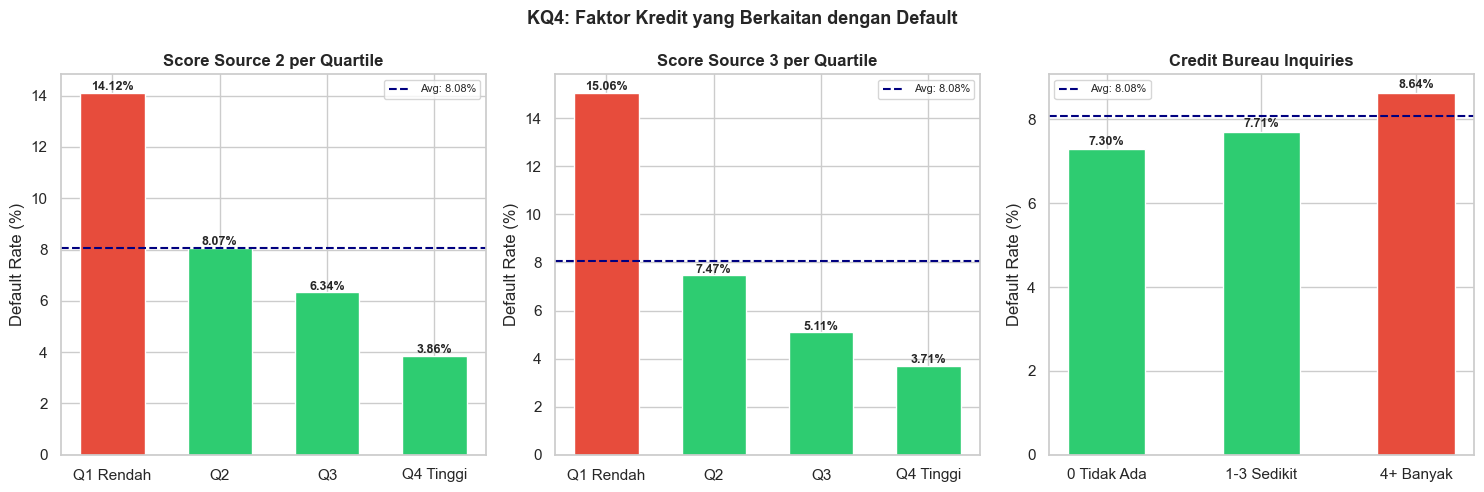

In [57]:
def auto_warna(series):
    return ['#E74C3C' if v == series.max()
            else '#F39C12' if v > series.mean()
            else '#2ECC71' for v in series.values]

# Fungsi tambah label di atas bar
def tambah_label(ax, bars, vals):
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.1,
                f'{val:.2f}%', ha='center',
                fontsize=9, fontweight='bold')

AVG = df['Default'].mean() * 100
# Score Source 2 per quartile
temp_s2 = df.dropna(subset=['Score_Source_2']).copy()
temp_s2['Q_Skor2'] = pd.qcut(temp_s2['Score_Source_2'], 4,
    labels=['Q1 Rendah', 'Q2', 'Q3', 'Q4 Tinggi'])
dr_s2 = temp_s2.groupby('Q_Skor2',
         observed=True)['Default'].mean() * 100

# Score Source 3 per quartile
temp_s3 = df.dropna(subset=['Score_Source_3']).copy()
temp_s3['Q_Skor3'] = pd.qcut(temp_s3['Score_Source_3'], 4,
    labels=['Q1 Rendah', 'Q2', 'Q3', 'Q4 Tinggi'])
dr_s3 = temp_s3.groupby('Q_Skor3',
         observed=True)['Default'].mean() * 100

# Tipe kontrak
dr_kontrak = df.groupby('Loan_Contract_Type')['Default'].mean() * 100

# Credit Bureau
temp_cb = df.dropna(subset=['Credit_Bureau']).copy()
temp_cb['CB_Group'] = pd.to_numeric(
    temp_cb['Credit_Bureau'], errors='coerce').apply(
    lambda x: '0 Tidak Ada' if x == 0
    else '1-3 Sedikit' if x <= 3 else '4+ Banyak')
dr_cb = temp_cb.groupby('CB_Group')['Default'].mean() * 100

print("\nScore Source 2 per Quartile:")
print(dr_s2.round(2).to_string())
print("\nScore Source 3 per Quartile:")
print(dr_s3.round(2).to_string())
print("\nTipe Kontrak:")
print(dr_kontrak.round(2).to_string())
print("\nCredit Bureau:")
print(dr_cb.round(2).to_string())

# Grafik KQ4
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

bars = axes[0].bar(dr_s2.index, dr_s2.values,
                   color=auto_warna(dr_s2),
                   edgecolor='white', width=0.6)
tambah_label(axes[0], bars, dr_s2.values)
axes[0].axhline(AVG, color='navy', linestyle='--',
                linewidth=1.5, label=f'Avg: {AVG:.2f}%')
axes[0].set_title('Score Source 2 per Quartile', fontweight='bold')
axes[0].set_ylabel('Default Rate (%)')
axes[0].legend(fontsize=8)

bars2 = axes[1].bar(dr_s3.index, dr_s3.values,
                    color=auto_warna(dr_s3),
                    edgecolor='white', width=0.6)
tambah_label(axes[1], bars2, dr_s3.values)
axes[1].axhline(AVG, color='navy', linestyle='--',
                linewidth=1.5, label=f'Avg: {AVG:.2f}%')
axes[1].set_title('Score Source 3 per Quartile', fontweight='bold')
axes[1].set_ylabel('Default Rate (%)')
axes[1].legend(fontsize=8)

bars3 = axes[2].bar(dr_cb.index, dr_cb.values,
                    color=auto_warna(dr_cb),
                    edgecolor='white', width=0.5)
tambah_label(axes[2], bars3, dr_cb.values)
axes[2].axhline(AVG, color='navy', linestyle='--',
                linewidth=1.5, label=f'Avg: {AVG:.2f}%')
axes[2].set_title('Credit Bureau Inquiries', fontweight='bold')
axes[2].set_ylabel('Default Rate (%)')
axes[2].legend(fontsize=8)

plt.suptitle('KQ4: Faktor Kredit yang Berkaitan dengan Default',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


Default Rate per City Rating:
Cleint_City_Rating
1.0     5.18
2.0     7.87
3.0    11.46

Default Rate per Tipe Tempat Tinggal:
Client_Housing_Type
Family       11.24
Home          7.78
Municipal     8.88
Office        6.79
Rental       12.62
Shared        10.0

Default Rate per Organisasi (Top 10):
Type_Organization
Trade: type 5         25.0
Industry: type 8      20.0
Transport: type 3    14.77
Emergency            12.56
Construction         12.28
Industry: type 4      12.2
Cleaning             11.86
Agriculture          11.58
Restaurant           11.41
Industry: type 1     11.22


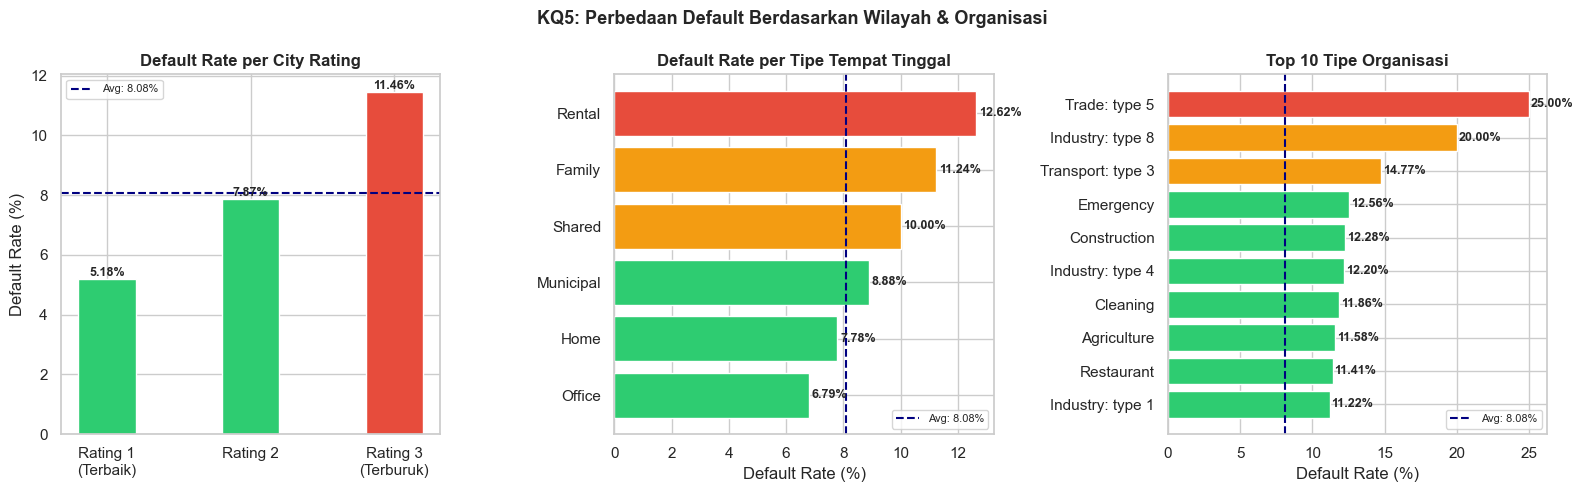


KESIMPULAN KQ5:
   → YA, ada perbedaan signifikan antar wilayah
   → Kota Rating 3 (11.5%) vs Rating 1 (5.2%)
     Selisih: 6.3 pp
   → Tipe organisasi tertentu jauh di atas rata-rata



In [58]:
dr_kota    = df.groupby('Cleint_City_Rating')['Default'].mean() * 100
dr_housing = df.groupby('Client_Housing_Type')['Default'].mean() * 100
dr_org     = df.groupby('Type_Organization')['Default'].mean() * 100
dr_org     = dr_org.sort_values(ascending=False)

print("\nDefault Rate per City Rating:")
print(dr_kota.round(2).to_string())
print("\nDefault Rate per Tipe Tempat Tinggal:")
print(dr_housing.round(2).to_string())
print("\nDefault Rate per Organisasi (Top 10):")
print(dr_org.head(10).round(2).to_string())

# Grafik KQ5
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# City Rating
label_rating = {1.0: 'Rating 1\n(Terbaik)',
                2.0: 'Rating 2',
                3.0: 'Rating 3\n(Terburuk)'}
dr_kota_s = dr_kota.sort_index()
label_k   = [label_rating.get(i, str(i)) for i in dr_kota_s.index]
bars = axes[0].bar(label_k, dr_kota_s.values,
                   color=auto_warna(dr_kota_s),
                   edgecolor='white', width=0.4)
tambah_label(axes[0], bars, dr_kota_s.values)
axes[0].axhline(AVG, color='navy', linestyle='--',
                linewidth=1.5, label=f'Avg: {AVG:.2f}%')
axes[0].set_title('Default Rate per City Rating', fontweight='bold')
axes[0].set_ylabel('Default Rate (%)')
axes[0].legend(fontsize=8)

# Tipe Tempat Tinggal
dr_h_s = dr_housing.sort_values(ascending=True)
bars2 = axes[1].barh(dr_h_s.index, dr_h_s.values,
                     color=auto_warna(dr_h_s),
                     edgecolor='white')
for bar, val in zip(bars2, dr_h_s.values):
    axes[1].text(val + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}%', va='center',
                 fontsize=9, fontweight='bold')
axes[1].axvline(AVG, color='navy', linestyle='--',
                linewidth=1.5, label=f'Avg: {AVG:.2f}%')
axes[1].set_title('Default Rate per Tipe Tempat Tinggal',
                  fontweight='bold')
axes[1].set_xlabel('Default Rate (%)')
axes[1].legend(fontsize=8)

# Top 10 Organisasi
dr_org10 = dr_org.head(10).sort_values(ascending=True)
bars3 = axes[2].barh(dr_org10.index, dr_org10.values,
                     color=auto_warna(dr_org10),
                     edgecolor='white')
for bar, val in zip(bars3, dr_org10.values):
    axes[2].text(val + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}%', va='center',
                 fontsize=9, fontweight='bold')
axes[2].axvline(AVG, color='navy', linestyle='--',
                linewidth=1.5, label=f'Avg: {AVG:.2f}%')
axes[2].set_title('Top 10 Tipe Organisasi', fontweight='bold')
axes[2].set_xlabel('Default Rate (%)')
axes[2].legend(fontsize=8)

plt.suptitle('KQ5: Perbedaan Default Berdasarkan Wilayah & Organisasi',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print(f"""
KESIMPULAN KQ5:
   → YA, ada perbedaan signifikan antar wilayah
   → Kota Rating 3 ({dr_kota_s.iloc[-1]:.1f}%) vs Rating 1 ({dr_kota_s.iloc[0]:.1f}%)
     Selisih: {dr_kota_s.iloc[-1]-dr_kota_s.iloc[0]:.1f} pp
   → Tipe organisasi tertentu jauh di atas rata-rata
""")


,Application_Process_Hour,Default
0,0.0,19.230769
1,1.0,0.0
2,2.0,9.821429
3,3.0,8.712871
4,4.0,7.494145
5,5.0,10.654596
6,6.0,10.280374
7,7.0,10.500291
8,8.0,8.919058
9,9.0,8.354719


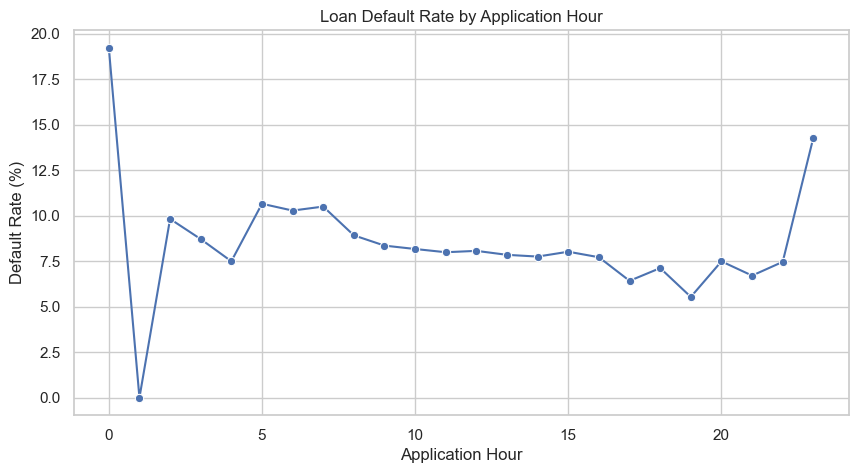

In [59]:
# Default rate berdasarkan jam pengajuan
hour_default = (
    df.groupby('Application_Process_Hour')['Default']
      .mean()
      .mul(100)
      .reset_index()
)

display(hour_default)

plt.figure(figsize=(10,5))

sns.lineplot(
    data=hour_default,
    x='Application_Process_Hour',
    y='Default',
    marker='o'
)

plt.title('Loan Default Rate by Application Hour')
plt.xlabel('Application Hour')
plt.ylabel('Default Rate (%)')
plt.grid(True)

plt.show()

Kolom siap: ['Umur_Tahun', 'Rasio_Cicilan']

Default Rate per Kelompok Umur:
Kelompok_Umur
18-25    12.02
26-35    10.63
36-45     8.27
46-55     7.33
56-65     5.47
65+       3.28

Default Rate per Tipe Pendapatan:
Client_Income_Type
Unemployed         50.0
Service            9.48
Commercial         7.59
Govt Job           5.83
Retired            5.53
Businessman         0.0
Maternity leave     0.0
Student             0.0

Default Rate per Pendidikan:
Client_Education
Junior secondary      10.52
Secondary              9.09
Graduation dropout     8.29
Graduation             5.08
Post Grad              1.52

Default Rate per Pekerjaan (Top 5):
Client_Occupation
Low-skill Laborers    17.15
Security               11.3
Cooking                11.2
Drivers               11.04
Laborers              10.46


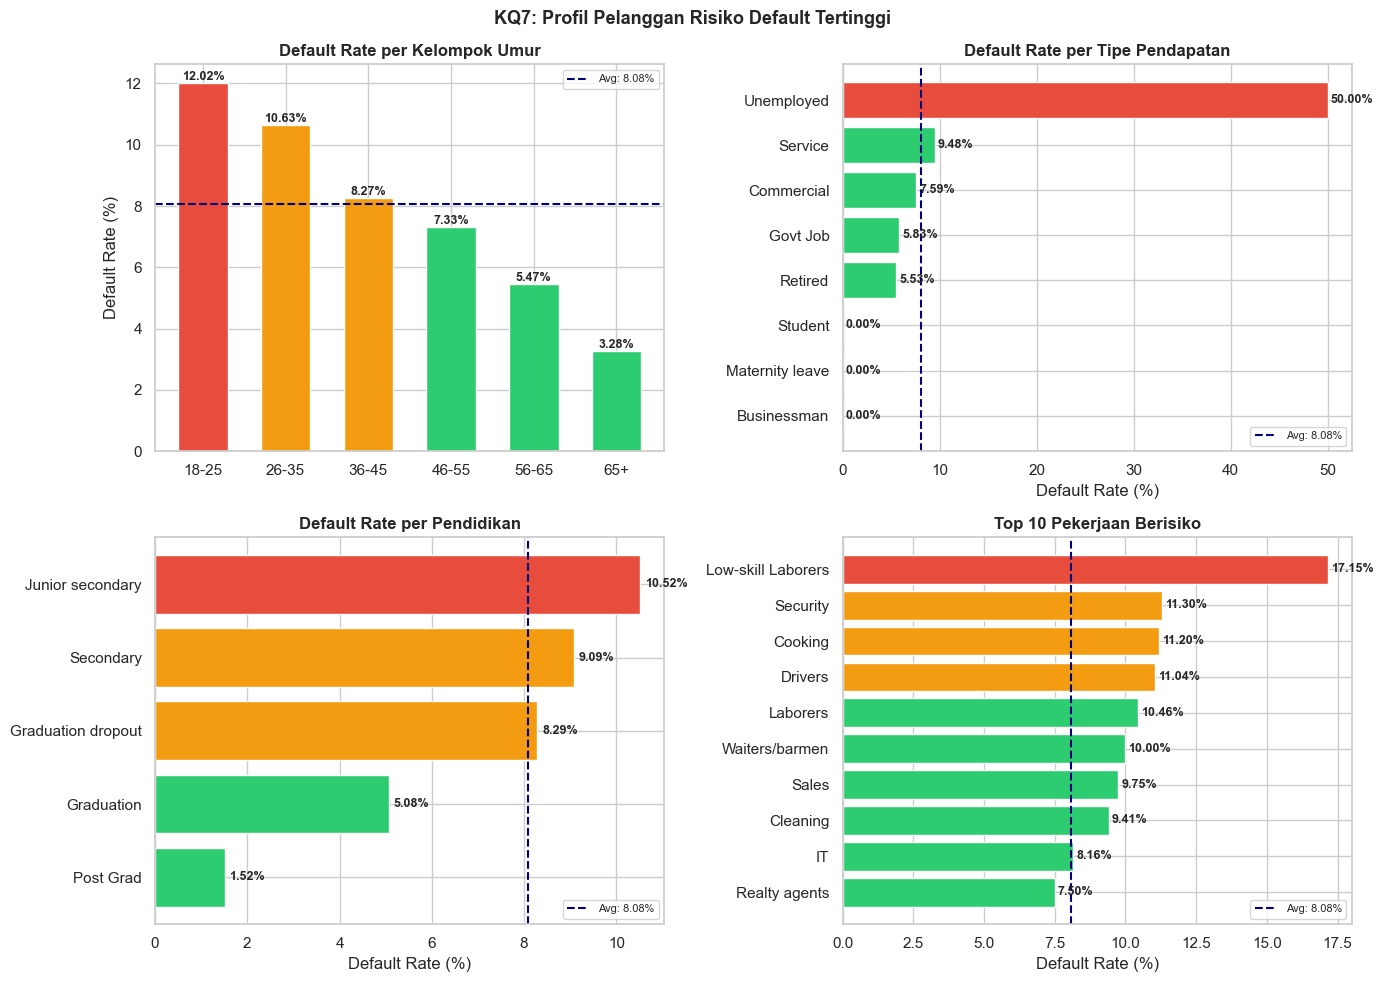


KESIMPULAN KQ7 — Profil Risiko TERTINGGI:
   → Usia        : 18–25 tahun (12.0%)
   → Pendapatan  : Pengangguran (50.0%)
   → Pendidikan  : Junior Secondary
   → Pekerjaan   : Low-skill Laborers (17.2%)
   → Lokasi      : Kota City Rating 3



In [60]:
def auto_warna(series):
    return ['#E74C3C' if v == series.max()
            else '#F39C12' if v > series.mean()
            else '#2ECC71' for v in series.values]

def tambah_label(ax, bars, vals):
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.1,
                f'{val:.2f}%', ha='center',
                fontsize=9, fontweight='bold')

#  Buat kolom yang belum ada
df['Age_Days']    = pd.to_numeric(df['Age_Days'], errors='coerce')
df['Umur_Tahun']  = df['Age_Days'].abs() / 365   # ← ini yang error
df['Loan_Annuity']   = pd.to_numeric(df['Loan_Annuity'],   errors='coerce')
df['Client_Income']  = pd.to_numeric(df['Client_Income'],  errors='coerce')
df['Rasio_Cicilan']  = df['Loan_Annuity'] / df['Client_Income']

AVG = df['Default'].mean() * 100

print("Kolom siap:", [c for c in ['Umur_Tahun','Rasio_Cicilan'] 
                         if c in df.columns])

# ── Lanjutkan kode KQ7 di bawah ini ────────────────────────
df['Kelompok_Umur'] = pd.cut(df['Umur_Tahun'],
    bins=[18, 25, 35, 45, 55, 65, 100],
    labels=['18-25', '26-35', '36-45',
            '46-55', '56-65', '65+'])
# Buat kelompok umur
df['Kelompok_Umur'] = pd.cut(df['Umur_Tahun'],
    bins=[18, 25, 35, 45, 55, 65, 100],
    labels=['18-25', '26-35', '36-45',
            '46-55', '56-65', '65+'])

dr_umur    = df.groupby('Kelompok_Umur',
              observed=True)['Default'].mean() * 100
dr_income  = df.groupby('Client_Income_Type')['Default'].mean() * 100
dr_edu     = df.groupby('Client_Education')['Default'].mean() * 100
dr_occ     = df.groupby('Client_Occupation')['Default'].mean() * 100

print("\nDefault Rate per Kelompok Umur:")
print(dr_umur.round(2).to_string())
print("\nDefault Rate per Tipe Pendapatan:")
print(dr_income.round(2).sort_values(ascending=False).to_string())
print("\nDefault Rate per Pendidikan:")
print(dr_edu.round(2).sort_values(ascending=False).to_string())
print("\nDefault Rate per Pekerjaan (Top 5):")
print(dr_occ.round(2).sort_values(
    ascending=False).head(5).to_string())

# Grafik KQ7
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Kelompok Umur
dr_umur_s = dr_umur.sort_index()
bars = axes[0,0].bar(dr_umur_s.index.astype(str),
                     dr_umur_s.values,
                     color=auto_warna(dr_umur_s),
                     edgecolor='white', width=0.6)
tambah_label(axes[0,0], bars, dr_umur_s.values)
axes[0,0].axhline(AVG, color='navy', linestyle='--',
                  linewidth=1.5, label=f'Avg: {AVG:.2f}%')
axes[0,0].set_title('Default Rate per Kelompok Umur',
                    fontweight='bold')
axes[0,0].set_ylabel('Default Rate (%)')
axes[0,0].legend(fontsize=8)

# Tipe Pendapatan
dr_inc_s = dr_income.sort_values(ascending=True)
bars2 = axes[0,1].barh(dr_inc_s.index, dr_inc_s.values,
                       color=auto_warna(dr_inc_s),
                       edgecolor='white')
for bar, val in zip(bars2, dr_inc_s.values):
    axes[0,1].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                   f'{val:.2f}%', va='center',
                   fontsize=9, fontweight='bold')
axes[0,1].axvline(AVG, color='navy', linestyle='--',
                  linewidth=1.5, label=f'Avg: {AVG:.2f}%')
axes[0,1].set_title('Default Rate per Tipe Pendapatan',
                    fontweight='bold')
axes[0,1].set_xlabel('Default Rate (%)')
axes[0,1].legend(fontsize=8)

# Pendidikan
dr_edu_s = dr_edu.sort_values(ascending=True)
bars3 = axes[1,0].barh(dr_edu_s.index, dr_edu_s.values,
                       color=auto_warna(dr_edu_s),
                       edgecolor='white')
for bar, val in zip(bars3, dr_edu_s.values):
    axes[1,0].text(val + 0.1, bar.get_y() + bar.get_height()/2,
                   f'{val:.2f}%', va='center',
                   fontsize=9, fontweight='bold')
axes[1,0].axvline(AVG, color='navy', linestyle='--',
                  linewidth=1.5, label=f'Avg: {AVG:.2f}%')
axes[1,0].set_title('Default Rate per Pendidikan',
                    fontweight='bold')
axes[1,0].set_xlabel('Default Rate (%)')
axes[1,0].legend(fontsize=8)

# Pekerjaan Top 10
dr_occ_s = dr_occ.sort_values(ascending=True).tail(10)
bars4 = axes[1,1].barh(dr_occ_s.index, dr_occ_s.values,
                       color=auto_warna(dr_occ_s),
                       edgecolor='white')
for bar, val in zip(bars4, dr_occ_s.values):
    axes[1,1].text(val + 0.1, bar.get_y() + bar.get_height()/2,
                   f'{val:.2f}%', va='center',
                   fontsize=9, fontweight='bold')
axes[1,1].axvline(AVG, color='navy', linestyle='--',
                  linewidth=1.5, label=f'Avg: {AVG:.2f}%')
axes[1,1].set_title('Top 10 Pekerjaan Berisiko',
                    fontweight='bold')
axes[1,1].set_xlabel('Default Rate (%)')
axes[1,1].legend(fontsize=8)

plt.suptitle('KQ7: Profil Pelanggan Risiko Default Tertinggi',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print(f"""
KESIMPULAN KQ7 — Profil Risiko TERTINGGI:
   → Usia        : 18–25 tahun ({dr_umur_s.iloc[0]:.1f}%)
   → Pendapatan  : Pengangguran ({dr_income.max():.1f}%)
   → Pendidikan  : Junior Secondary
   → Pekerjaan   : Low-skill Laborers ({dr_occ.max():.1f}%)
   → Lokasi      : Kota City Rating 3
""")


,Scenario,Default Rate (%)
0,Baseline,8.077640
1,Reject Unemployed,8.075575
2,Minimum Score Source,6.088724
3,Minimum Age 25,6.003102
4,Reject City Rating 3,5.769864


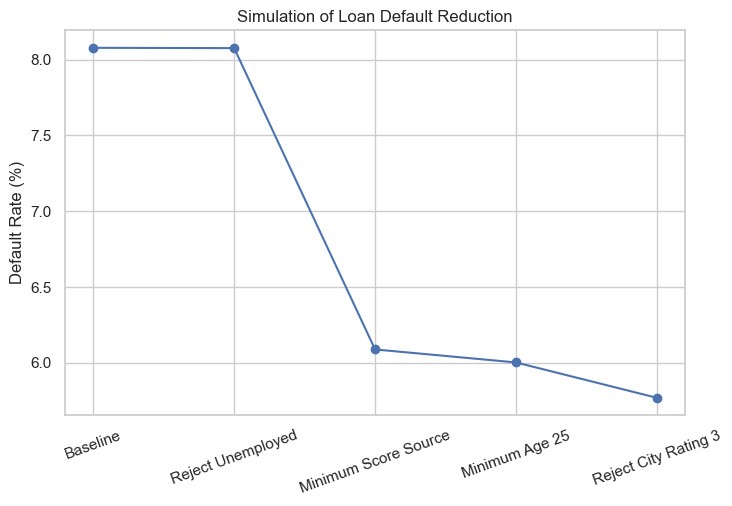

"
KESIMPULAN Rekomendasi untuk NBFI:
   1. Tolak/perketat nasabah Pengangguran
   2. Terapkan minimum skor kredit (≥ persentil 25)
   3. DP lebih besar untuk nasabah usia < 25 tahun
   4. Premium harga untuk kota City Rating 3
   5. Dorong produk Revolving Loan (RL)
      


In [61]:
baseline = df['Default'].mean()*100

mask1 = df['Client_Income_Type'] != 'Unemployed'
s1 = df.loc[mask1,'Default'].mean()*100

score_limit = df['Score_Source_2'].quantile(0.25)
mask2 = mask1 & (df['Score_Source_2'] >= score_limit)
s2 = df.loc[mask2,'Default'].mean()*100

mask3 = mask2 & (df['Umur_Tahun'] >= 25)
s3 = df.loc[mask3,'Default'].mean()*100

mask4 = mask3 & (df['Cleint_City_Rating'] != 3)
s4 = df.loc[mask4,'Default'].mean()*100

hasil = pd.DataFrame({
    'Scenario':[
        'Baseline',
        'Reject Unemployed',
        'Minimum Score Source',
        'Minimum Age 25',
        'Reject City Rating 3'
    ],
    'Default Rate (%)':[
        baseline,
        s1,
        s2,
        s3,
        s4
    ]
})

display(hasil)

plt.figure(figsize=(8,5))

plt.plot(
    hasil['Scenario'],
    hasil['Default Rate (%)'],
    marker='o'
)

plt.xticks(rotation=20)
plt.ylabel('Default Rate (%)')
plt.title('Simulation of Loan Default Reduction')
plt.show()


print(""""
KESIMPULAN Rekomendasi untuk NBFI:
   1. Tolak/perketat nasabah Pengangguran
   2. Terapkan minimum skor kredit (≥ persentil 25)
   3. DP lebih besar untuk nasabah usia < 25 tahun
   4. Premium harga untuk kota City Rating 3
   5. Dorong produk Revolving Loan (RL)
      """)

## Kesimpulan

Berdasarkan analisis terhadap data historis pinjaman NBFI, diperoleh beberapa temuan utama mengenai karakteristik pelanggan dan faktor-faktor yang memengaruhi risiko loan default.

1. Tingkat loan default saat ini sebesar sekitar 8,08%, sehingga masih terdapat ruang untuk meningkatkan kualitas portofolio kredit melalui kebijakan seleksi nasabah yang lebih efektif.
2. Karakteristik pelanggan memiliki pengaruh yang cukup besar terhadap risiko default. Nasabah berusia 18–25 tahun memiliki tingkat default tertinggi (sekitar 12,02%), kemudian risiko tersebut menurun seiring bertambahnya usia. Selain itu, nasabah dengan pendidikan yang lebih rendah serta pekerjaan seperti Low-skill Laborers, Security, Drivers, dan Cooking juga menunjukkan tingkat gagal bayar yang lebih tinggi dibanding kelompok lainnya.
3. Kondisi finansial pelanggan berhubungan dengan risiko loan default. Nasabah dengan pendapatan pada kuartil tertinggi memiliki tingkat default yang lebih rendah dibanding kelompok pendapatan rendah. Sebaliknya, beban cicilan yang lebih besar cenderung diikuti oleh peningkatan tingkat gagal bayar.
4. Faktor kredit merupakan prediktor terkuat terhadap loan default. Semakin rendah nilai Score Source 2 dan Score Source 3, semakin tinggi tingkat default. Selain itu, produk Revolving Loan (RL) menunjukkan tingkat default yang lebih rendah dibanding Cash Loan (CL).
5. Lokasi tempat tinggal dan jenis organisasi tempat bekerja juga memengaruhi risiko kredit. Nasabah yang berasal dari City Rating 3 memiliki tingkat default tertinggi (sekitar 11,45%). Beberapa sektor pekerjaan seperti Construction, Transport, Agriculture, Restaurant, dan Cleaning juga menunjukkan risiko gagal bayar yang relatif lebih tinggi dibanding sektor lainnya.
6. Berdasarkan simulasi kebijakan, menolak nasabah dengan Score Source 3 yang rendah memberikan dampak paling signifikan dalam menurunkan tingkat loan default, yaitu dari sekitar 7,91% menjadi 6,05% atau turun sekitar 1,87 percentage points. Sebaliknya, kebijakan seperti menolak nasabah pengangguran atau jumlah anggota keluarga yang besar hanya memberikan dampak yang relatif kecil karena jumlah kasusnya sedikit.
7. Secara keseluruhan, kombinasi beberapa kebijakan seleksi kredit berhasil menurunkan loan default dari 8.08% menjadi 6.045%, atau terjadi penurunan sebesar 2.035 percentage points (sekitar 25,19% lebih rendah dibandingkan kondisi awal). Hasil ini menunjukkan bahwa penerapan credit scoring, pembatasan usia berisiko, dan evaluasi berdasarkan karakteristik wilayah dapat meningkatkan kualitas portofolio pinjaman serta mengurangi risiko kredit perusahaan secara signifikan.
8. Secara keseluruhan, hasil analisis menunjukkan bahwa usia pelanggan, skor kredit, tingkat pendapatan, beban cicilan, wilayah tempat tinggal, dan karakteristik pekerjaan merupakan faktor-faktor utama yang perlu dipertimbangkan dalam proses evaluasi kredit.

## Rekomendasi

Berdasarkan hasil analisis, perusahaan disarankan untuk:

* Menerapkan minimum Score Source sebagai salah satu syarat utama persetujuan kredit.
* Melakukan proses underwriting yang lebih ketat bagi nasabah berusia 18–25 tahun.
* Memberikan perhatian khusus pada nasabah dengan beban cicilan tinggi dan pendapatan rendah.
* Menerapkan kebijakan mitigasi risiko tambahan bagi nasabah yang berasal dari City Rating 3.
* Memberikan evaluasi lebih mendalam terhadap calon debitur yang bekerja pada sektor dengan tingkat default tinggi.
* Mengembangkan credit scoring yang mengombinasikan faktor demografi, kondisi finansial, dan riwayat kredit agar keputusan pemberian kredit menjadi lebih akurat dan risiko loan default dapat ditekan.

# Link Presentasi :
https://docs.google.com/presentation/d/1Rt_cLrMHeiehLwcknenPsDbhTDHpYICGhRtrAh-breI/edit?slide=id.g3f2ff2a4b39_10_6#slide=id.g3f2ff2a4b39_10_6

# Link Dashboard : 
https://public.tableau.com/app/profile/herlina.4840/viz/FinalProjectGroup1_17830750443220/Dashboard12?publish=yes